In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Load data
df = pd.read_csv('../data/processed/cleaned_sales.csv', parse_dates=['InvoiceDate'])
forecast = pd.read_csv('../data/processed/30_day_forecast.csv')
forecast['ds'] = pd.to_datetime(forecast['ds'])

print("="*60)
print("INVENTORY OPTIMIZATION SYSTEM")
print("="*60)


INVENTORY OPTIMIZATION SYSTEM


In [14]:
product_metrics = df.groupby(['StockCode', 'Description']).agg({
    'Quantity': ['sum', 'mean', 'std', 'count'],
    'Invoice': 'nunique',
    'Price': 'first'
}).reset_index()

product_metrics.columns = ['StockCode', 'Description', 'total_sold', 'avg_daily_sales', 
                           'std_sales', 'order_count', 'unique_orders', 'unit_price']

# Fill NaN values with 0 for products with no sales variation
product_metrics['std_sales'] = product_metrics['std_sales'].fillna(0)
product_metrics['avg_daily_sales'] = product_metrics['avg_daily_sales'].fillna(0)

# Calculate date range in days
date_range_days = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days
if date_range_days == 0:
    date_range_days = 1

# Calculate lead time demand (assuming 7-day lead time)
product_metrics['lead_time_demand'] = product_metrics['avg_daily_sales'] * 7

# Calculate safety stock (using 95% service level - Z=1.645)
Z_score = 1.645  # 95% service level
product_metrics['safety_stock'] = Z_score * product_metrics['std_sales'] * np.sqrt(7)

# Calculate reorder point
product_metrics['reorder_point'] = product_metrics['lead_time_demand'] + product_metrics['safety_stock']

# Calculate economic order quantity (EOQ)
ordering_cost = 50
holding_cost_rate = 0.20

def calculate_eoq(row):
    if row['unit_price'] > 0 and row['avg_daily_sales'] > 0:
        annual_demand = row['total_sold'] * (365 / date_range_days)
        if holding_cost_rate * row['unit_price'] > 0:
            eoq = np.sqrt((2 * annual_demand * ordering_cost) / (holding_cost_rate * row['unit_price']))
            return round(eoq)
    return 0

product_metrics['eoq'] = product_metrics.apply(calculate_eoq, axis=1)

In [15]:
print("\nChecking for NaN values...")
print(f"NaN in reorder_point: {product_metrics['reorder_point'].isna().sum()}")
print(f"NaN in avg_daily_sales: {product_metrics['avg_daily_sales'].isna().sum()}")

# Fill any remaining NaN values
product_metrics['reorder_point'] = product_metrics['reorder_point'].fillna(0)
product_metrics['lead_time_demand'] = product_metrics['lead_time_demand'].fillna(0)
product_metrics['safety_stock'] = product_metrics['safety_stock'].fillna(0)

# Calculate current stock (simulated) - FIXED VERSION
np.random.seed(42)

def calculate_current_stock(row):
    if row['reorder_point'] > 0:
        # Ensure values are positive and convert to integers
        low = int(max(0, row['reorder_point'] * 0.5))
        high = int(max(low + 1, row['reorder_point'] * 1.5))
        if high > low:
            return np.random.randint(low, high)
        else:
            return low
    else:
        # For products with no sales history
        return np.random.randint(1, 50)

product_metrics['current_stock'] = product_metrics.apply(calculate_current_stock, axis=1)

# Calculate reorder quantity
product_metrics['reorder_quantity'] = product_metrics.apply(
    lambda x: max(0, x['eoq'] - x['current_stock']), axis=1
)

# Calculate stockout risk (with NaN handling)
def calculate_risk(row):
    if row['reorder_point'] == 0:
        return 'LOW'
    elif row['current_stock'] < row['reorder_point'] * 0.7:
        return 'HIGH'
    elif row['current_stock'] < row['reorder_point']:
        return 'MEDIUM'
    else:
        return 'LOW'

product_metrics['stockout_risk'] = product_metrics.apply(calculate_risk, axis=1)


Checking for NaN values...
NaN in reorder_point: 0
NaN in avg_daily_sales: 0


In [16]:
print(f"\n📊 INVENTORY METRICS:")
print(f"   Total Products: {len(product_metrics)}")
print(f"   Products with sales: {(product_metrics['total_sold'] > 0).sum()}")
print(f"   Products with zero sales: {(product_metrics['total_sold'] == 0).sum()}")

# Identify products needing reorder
critical_products = product_metrics[
    (product_metrics['current_stock'] < product_metrics['reorder_point']) & 
    (product_metrics['reorder_point'] > 0)
].sort_values('stockout_risk', ascending=False)

print(f"\n📦 CRITICAL PRODUCTS (Need Immediate Reorder):")
print(f"   Count: {len(critical_products)}")

if len(critical_products) > 0:
    print("\nTop 10 critical products:")
    print(critical_products[['Description', 'current_stock', 'reorder_point', 
                             'reorder_quantity', 'stockout_risk']].head(10).to_string())
else:
    print("   No critical products found!")


📊 INVENTORY METRICS:
   Total Products: 5257
   Products with sales: 5257
   Products with zero sales: 0

📦 CRITICAL PRODUCTS (Need Immediate Reorder):
   Count: 2748

Top 10 critical products:
                           Description  current_stock  reorder_point  reorder_quantity stockout_risk
1             GROOVY CACTUS INFLATABLE            114     127.280148               183        MEDIUM
3033  PHOTO FRAME LINEN AND LACE SMALL             42      47.304614               150        MEDIUM
3079        SQUARE MINI PORTRAIT FRAME             40      54.436851               136        MEDIUM
3078    SET OF 6 EASTER RAINBOW CHICKS             71      84.000000                 0        MEDIUM
3067           RED SPOT GIFT BAG LARGE            117     118.881804               365        MEDIUM
3066     GIFT BAG LARGE 50'S CHRISTMAS             64      84.000000                 5        MEDIUM
3059     PRETTY HANGING QUILTED HEARTS            106     136.770856               436        MEDI

In [17]:
product_metrics['inventory_value'] = product_metrics['current_stock'] * product_metrics['unit_price']
product_metrics['reorder_value'] = product_metrics['reorder_quantity'] * product_metrics['unit_price']

total_inventory_value = product_metrics['inventory_value'].sum()
total_reorder_value = product_metrics['reorder_value'].sum()

print(f"\n💰 FINANCIAL METRICS:")
print(f"   Total Inventory Value: £{total_inventory_value:,.2f}")
print(f"   Recommended Reorder Value: £{total_reorder_value:,.2f}")
print(f"   Products Below Reorder Point: {(product_metrics['current_stock'] < product_metrics['reorder_point']).sum()}")
print(f"   Average Service Level Target: 95%")


💰 FINANCIAL METRICS:
   Total Inventory Value: £680,845.57
   Recommended Reorder Value: £2,045,529.90
   Products Below Reorder Point: 2748
   Average Service Level Target: 95%


In [18]:
def get_optimization_strategy(row):
    if row['reorder_point'] == 0:
        return "No sales history - Monitor"
    elif row['stockout_risk'] == 'HIGH':
        return "URGENT: Place order immediately"
    elif row['stockout_risk'] == 'MEDIUM':
        return "Monitor: Consider ordering within 3 days"
    elif row['reorder_quantity'] > 0:
        return "Reorder with next cycle"
    else:
        return "Sufficient stock"

product_metrics['optimization_strategy'] = product_metrics.apply(get_optimization_strategy, axis=1)


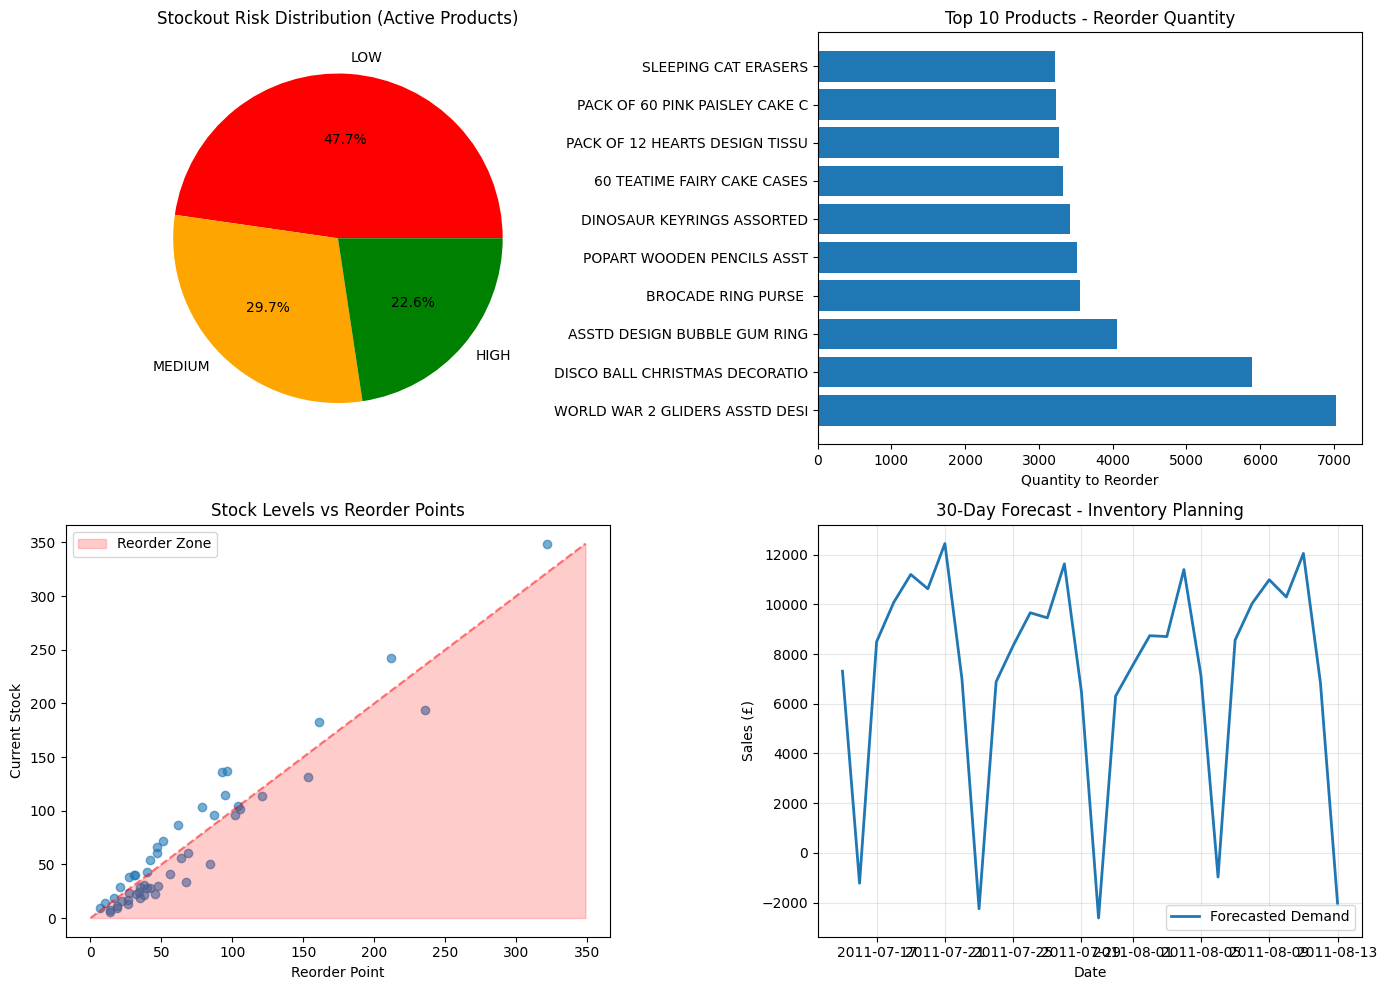

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Stockout risk distribution
risk_counts = product_metrics[product_metrics['reorder_point'] > 0]['stockout_risk'].value_counts()
if len(risk_counts) > 0:
    axes[0,0].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
                  colors=['red', 'orange', 'green'])
    axes[0,0].set_title('Stockout Risk Distribution (Active Products)')
else:
    axes[0,0].text(0.5, 0.5, 'No active products', ha='center', va='center')
    axes[0,0].set_title('Stockout Risk Distribution')

# Top products by reorder quantity
top_reorder = product_metrics.nlargest(10, 'reorder_quantity')
if len(top_reorder) > 0:
    axes[0,1].barh(range(len(top_reorder)), top_reorder['reorder_quantity'].values)
    axes[0,1].set_yticks(range(len(top_reorder)))
    axes[0,1].set_yticklabels([desc[:30] for desc in top_reorder['Description'].values])
    axes[0,1].set_title('Top 10 Products - Reorder Quantity')
    axes[0,1].set_xlabel('Quantity to Reorder')
else:
    axes[0,1].text(0.5, 0.5, 'No reorder recommendations', ha='center', va='center')
    axes[0,1].set_title('Top Products - Reorder Quantity')

# Current stock vs reorder point (only products with reorder_point > 0)
active_products = product_metrics[product_metrics['reorder_point'] > 0].sample(min(50, len(product_metrics)))
if len(active_products) > 0:
    axes[1,0].scatter(active_products['reorder_point'], active_products['current_stock'], alpha=0.6)
    max_val = max(active_products['reorder_point'].max(), active_products['current_stock'].max())
    axes[1,0].plot([0, max_val], [0, max_val], 'r--', alpha=0.5)
    axes[1,0].set_xlabel('Reorder Point')
    axes[1,0].set_ylabel('Current Stock')
    axes[1,0].set_title('Stock Levels vs Reorder Points')
    axes[1,0].fill_between([0, max_val], 0, [0, max_val], alpha=0.2, color='red', label='Reorder Zone')
    axes[1,0].legend()
else:
    axes[1,0].text(0.5, 0.5, 'No active products with reorder points', ha='center', va='center')
    axes[1,0].set_title('Stock Levels vs Reorder Points')

# Forecast vs inventory
if len(forecast) > 0:
    axes[1,1].plot(forecast['ds'][:30], forecast['yhat'][:30], label='Forecasted Demand', linewidth=2)
    axes[1,1].set_xlabel('Date')
    axes[1,1].set_ylabel('Sales (£)')
    axes[1,1].set_title('30-Day Forecast - Inventory Planning')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
else:
    axes[1,1].text(0.5, 0.5, 'No forecast data available', ha='center', va='center')
    axes[1,1].set_title('30-Day Forecast')

plt.tight_layout()
plt.savefig('../data/processed/inventory_optimization.png')
plt.show()


In [20]:
inventory_report = product_metrics[[
    'StockCode', 'Description', 'current_stock', 'reorder_point', 
    'reorder_quantity', 'stockout_risk', 'optimization_strategy', 'inventory_value'
]].sort_values('stockout_risk', ascending=False)

inventory_report.to_csv('../data/processed/inventory_recommendations.csv', index=False)
print("\n✅ Inventory recommendations saved to: ../data/processed/inventory_recommendations.csv")

# Cell 9: Cost savings calculation
if total_reorder_value > 0:
    estimated_savings = {
        'reduced_stockouts': total_reorder_value * 0.15,
        'reduced_holding_cost': total_inventory_value * 0.10,
        'improved_turnover': total_reorder_value * 0.20
    }
    
    print(f"\n💰 ESTIMATED COST SAVINGS:")
    for key, value in estimated_savings.items():
        print(f"   {key.replace('_', ' ').title()}: £{value:,.2f}")
    print(f"\n   Total Estimated Savings: £{sum(estimated_savings.values()):,.2f}")
else:
    print("\n⚠️ No reorder value calculated - check data")


✅ Inventory recommendations saved to: ../data/processed/inventory_recommendations.csv

💰 ESTIMATED COST SAVINGS:
   Reduced Stockouts: £306,829.48
   Reduced Holding Cost: £68,084.56
   Improved Turnover: £409,105.98

   Total Estimated Savings: £784,020.02


In [21]:
print("\n" + "="*60)
print("INVENTORY OPTIMIZATION SUMMARY")
print("="*60)
print(f"""
Active Products (with sales): {(product_metrics['total_sold'] > 0).sum()}
Zero Sales Products: {(product_metrics['total_sold'] == 0).sum()}
High Risk Products: {(product_metrics['stockout_risk'] == 'HIGH').sum()}
Medium Risk Products: {(product_metrics['stockout_risk'] == 'MEDIUM').sum()}
Low Risk Products: {(product_metrics['stockout_risk'] == 'LOW').sum()}

Recommendations:
- Immediate orders needed: {(product_metrics['optimization_strategy'] == 'URGENT: Place order immediately').sum()}
- Monitor within 3 days: {(product_metrics['optimization_strategy'] == 'Monitor: Consider ordering within 3 days').sum()}
- Next cycle orders: {(product_metrics['optimization_strategy'] == 'Reorder with next cycle').sum()}
""")


INVENTORY OPTIMIZATION SUMMARY

Active Products (with sales): 5257
Zero Sales Products: 0
High Risk Products: 1189
Medium Risk Products: 1559
Low Risk Products: 2509

Recommendations:
- Immediate orders needed: 1189
- Monitor within 3 days: 1559
- Next cycle orders: 2132

